<a href="https://colab.research.google.com/github/nayanshree42/customer-churn-prediction-xgboost/blob/main/notebooks/churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔍 Customer Churn Prediction with Explainable ML
### An end-to-end pipeline: Feature Engineering → Model Comparison → Hyperparameter Tuning → SHAP Explainability

**Dataset:** IBM Telco Customer Churn  
**Models:** Logistic Regression, Random Forest, XGBoost  
**Explainability:** SHAP (SHapley Additive exPlanations)

In [1]:
# Install dependencies
!pip install -q xgboost shap

# Clone repo structure (run once in Colab)
import os

for folder in ['data', 'outputs/plots', 'outputs/models', 'src']:
    os.makedirs(folder, exist_ok=True)

print("✅ Directories ready")

✅ Directories ready


In [5]:
!pip install -q kagglehub

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay
)
from xgboost import XGBClassifier
import shap

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print("✅ Libraries loaded")

✅ Libraries loaded


## 📥 1. Data Loading
I use the **IBM Telco Customer Churn** dataset, publicly available on Kaggle.
It contains 7,043 rows and 21 features including demographics, service details, and billing info.

In [6]:
import kagglehub
import pandas as pd
import os

# Download dataset directly
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
csv_file = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")
df_raw = pd.read_csv(csv_file)

print(f"Shape: {df_raw.shape}")
print(f"Churn Rate: {df_raw['Churn'].value_counts(normalize=True).round(3).to_dict()}")
df_raw.head()

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Shape: (7043, 21)
Churn Rate: {'No': 0.735, 'Yes': 0.265}


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 📊 2. Exploratory Data Analysis

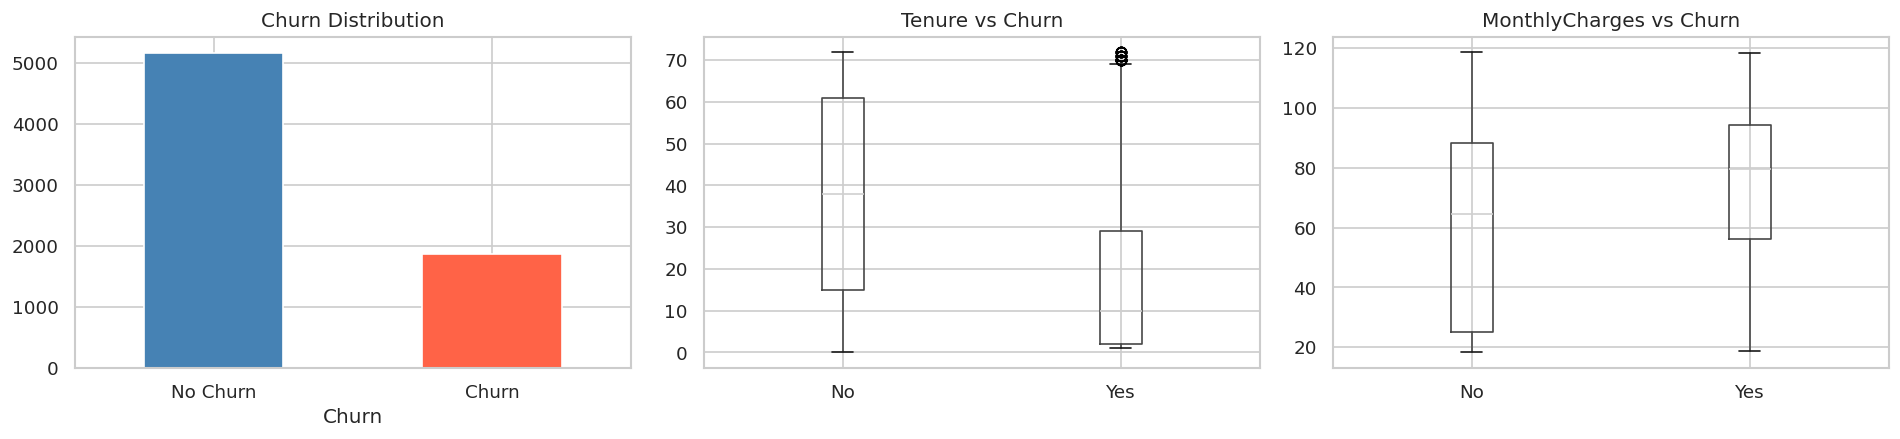


Missing values:
 Series([], dtype: int64)

Dtypes with object:
 ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Churn distribution
df_raw['Churn'].value_counts().plot(kind='bar', ax=axes[0],
    color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Churn Distribution')
axes[0].set_xticklabels(['No Churn', 'Churn'], rotation=0)

# Tenure vs Churn
df_raw.boxplot(column='tenure', by='Churn', ax=axes[1])
axes[1].set_title('Tenure vs Churn')
axes[1].set_xlabel('')

# Monthly Charges vs Churn
df_raw.boxplot(column='MonthlyCharges', by='Churn', ax=axes[2])
axes[2].set_title('MonthlyCharges vs Churn')
axes[2].set_xlabel('')

plt.suptitle('')
plt.tight_layout()
plt.savefig('outputs/plots/eda_overview.png', bbox_inches='tight')
plt.show()

# Missing values
print("\nMissing values:\n", df_raw.isnull().sum()[df_raw.isnull().sum() > 0])
print("\nDtypes with object:\n", df_raw.select_dtypes('object').columns.tolist())

## 🛠️ 3. Feature Engineering
- Clean & encode all categorical columns  
- Derive new features: `tenure_group`, `charges_per_month_ratio`, `is_long_term`  
- Scale numeric features

In [8]:
def load_and_clean(df):
    df = df.copy()
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
    df.drop(columns=['customerID'], inplace=True, errors='ignore')
    return df


def encode_features(df):
    df = df.copy()
    binary_map = {'Yes': 1, 'No': 0,
                  'No phone service': 0, 'No internet service': 0}

    binary_cols = [
        'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn',
        'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
        'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
    ]
    for col in binary_cols:
        if col in df.columns:
            df[col] = df[col].map(binary_map)

    df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
    cat_cols = df.select_dtypes(include='object').columns.tolist()
    if cat_cols:
        df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
    return df


def engineer_features(df):
    df = df.copy()
    df['tenure_group'] = pd.cut(
        df['tenure'],
        bins=[0, 12, 24, 48, 60, 72],
        labels=['0-1yr', '1-2yr', '2-4yr', '4-5yr', '5+yr']
    )
    df = pd.get_dummies(df, columns=['tenure_group'], drop_first=True)
    df['charges_per_month_ratio'] = df['TotalCharges'] / (df['tenure'] + 1)
    df['is_long_term'] = (df['tenure'] > 24).astype(int)
    return df


# Run pipeline
df_clean   = load_and_clean(df_raw)
df_encoded = encode_features(df_clean)
df_eng     = engineer_features(df_encoded)

print(f"Final shape: {df_eng.shape}")
print(f"Features: {df_eng.columns.tolist()}")
df_eng.head(3)

Final shape: (7043, 30)
Features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'tenure_group_1-2yr', 'tenure_group_2-4yr', 'tenure_group_4-5yr', 'tenure_group_5+yr', 'charges_per_month_ratio', 'is_long_term']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1-2yr,tenure_group_2-4yr,tenure_group_4-5yr,tenure_group_5+yr,charges_per_month_ratio,is_long_term
0,0,0,1,0,1,0,0,0,1,0,...,False,False,True,False,False,False,False,False,14.925000,0
1,1,0,0,0,34,1,0,1,0,1,...,False,False,False,True,False,True,False,False,53.985714,1
2,1,0,0,0,2,1,0,1,1,0,...,False,False,False,True,False,False,False,False,36.050000,0


In [9]:
TARGET = 'Churn'
NUMERIC_COLS = ['tenure', 'MonthlyCharges', 'TotalCharges', 'charges_per_month_ratio']

X = df_eng.drop(columns=[TARGET])
y = df_eng[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train[NUMERIC_COLS] = scaler.fit_transform(X_train[NUMERIC_COLS])
X_test[NUMERIC_COLS]  = scaler.transform(X_test[NUMERIC_COLS])

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Churn rate (train): {y_train.mean():.3f}")

Train: (5634, 29) | Test: (1409, 29)
Churn rate (train): 0.265


## 🤖 4. Model Comparison
Compare Logistic Regression, Random Forest, and XGBoost using 5-fold stratified cross-validation (ROC-AUC).

Logistic Regression       AUC = 0.8484 ± 0.0117
Random Forest             AUC = 0.8241 ± 0.0121
XGBoost                   AUC = 0.8220 ± 0.0095


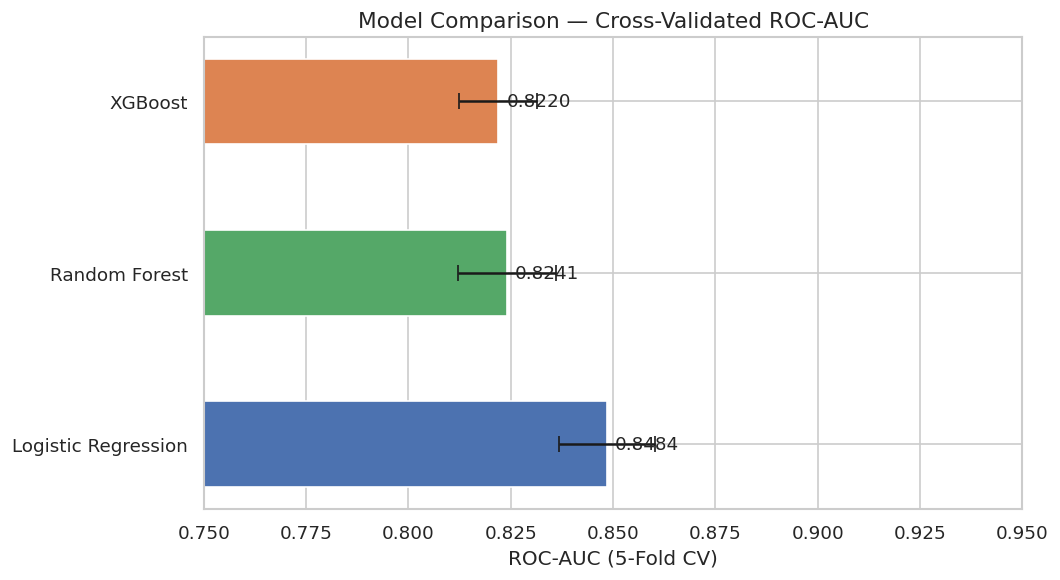

In [10]:
from sklearn.model_selection import cross_val_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(use_label_encoder=False,
                                          eval_metric='logloss', random_state=42)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train,
                             cv=skf, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:25s} AUC = {scores.mean():.4f} ± {scores.std():.4f}")

# Plot comparison
fig, ax = plt.subplots(figsize=(9, 5))
labels = list(cv_results.keys())
means  = [v.mean() for v in cv_results.values()]
stds   = [v.std()  for v in cv_results.values()]
colors = ['#4C72B0', '#55A868', '#DD8452']

bars = ax.barh(labels, means, xerr=stds, color=colors,
               edgecolor='white', capsize=5, height=0.5)
ax.set_xlim(0.75, 0.95)
ax.set_xlabel('ROC-AUC (5-Fold CV)', fontsize=12)
ax.set_title('Model Comparison — Cross-Validated ROC-AUC', fontsize=13)
for bar, mean in zip(bars, means):
    ax.text(mean + 0.002, bar.get_y() + bar.get_height()/2,
            f'{mean:.4f}', va='center', fontsize=11)
plt.tight_layout()
plt.savefig('outputs/plots/model_comparison.png', bbox_inches='tight')
plt.show()

## 🎯 5. Hyperparameter Tuning — XGBoost
Using `RandomizedSearchCV` with 30 iterations across a broad parameter space.

In [11]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [3, 4, 5, 6],
    'learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'subsample':         [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree':  [0.6, 0.7, 0.8, 1.0],
    'min_child_weight':  [1, 3, 5],
    'gamma':             [0, 0.1, 0.2],
    'reg_alpha':         [0, 0.1, 0.5],
    'reg_lambda':        [1, 1.5, 2]
}

xgb_base = XGBClassifier(use_label_encoder=False,
                          eval_metric='logloss',
                          random_state=42)

search = RandomizedSearchCV(
    xgb_base, param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    verbose=1,
    n_jobs=-1,
    random_state=42
)
search.fit(X_train, y_train)

best_xgb = search.best_estimator_
print(f"\n✅ Best CV AUC: {search.best_score_:.4f}")
print(f"Best Params:\n{search.best_params_}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Best CV AUC: 0.8499
Best Params:
{'subsample': 0.6, 'reg_lambda': 2, 'reg_alpha': 0.5, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.6}


## 📈 6. Model Evaluation on Test Set
Evaluate all 3 models + tuned XGBoost with ROC-AUC, Confusion Matrix, and Classification Report.


  Logistic Regression  —  AUC: 0.8467
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.67      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409



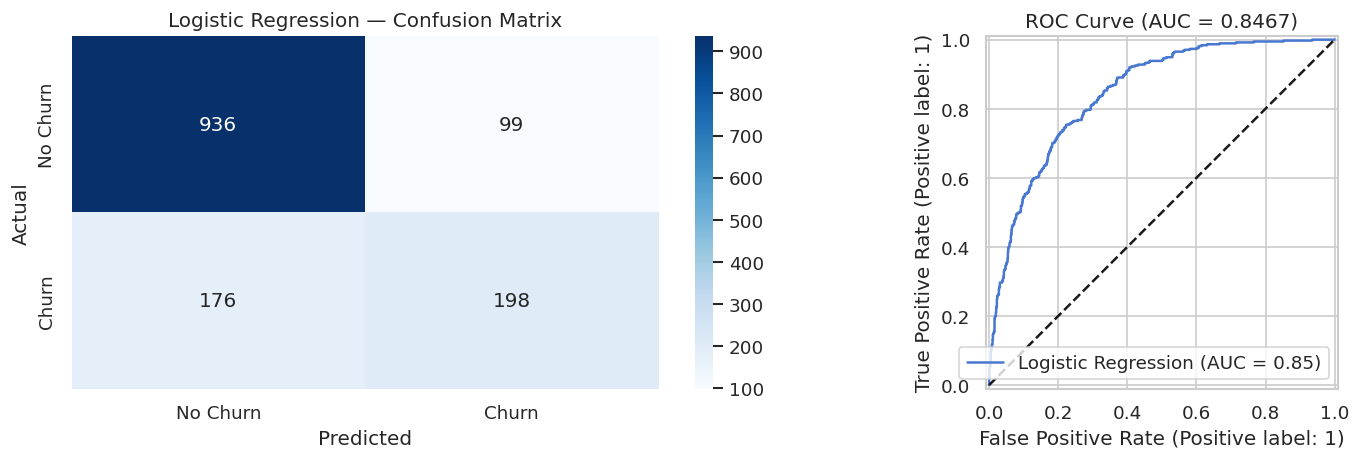


  Random Forest  —  AUC: 0.8219
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1035
       Churn       0.63      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



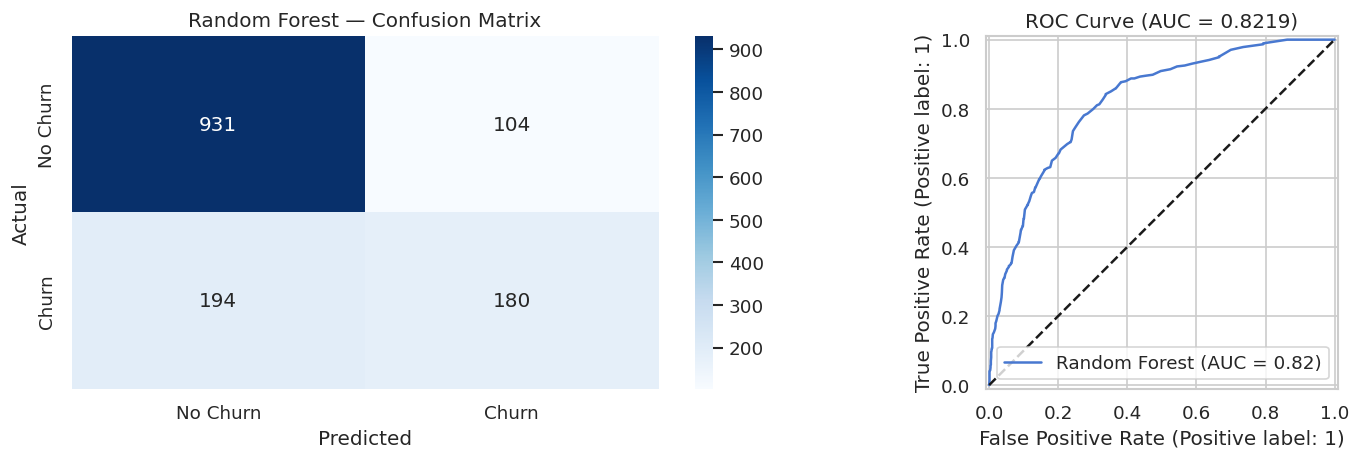


  XGBoost (Default)  —  AUC: 0.8190
              precision    recall  f1-score   support

    No Churn       0.84      0.88      0.86      1035
       Churn       0.61      0.52      0.56       374

    accuracy                           0.78      1409
   macro avg       0.72      0.70      0.71      1409
weighted avg       0.77      0.78      0.78      1409



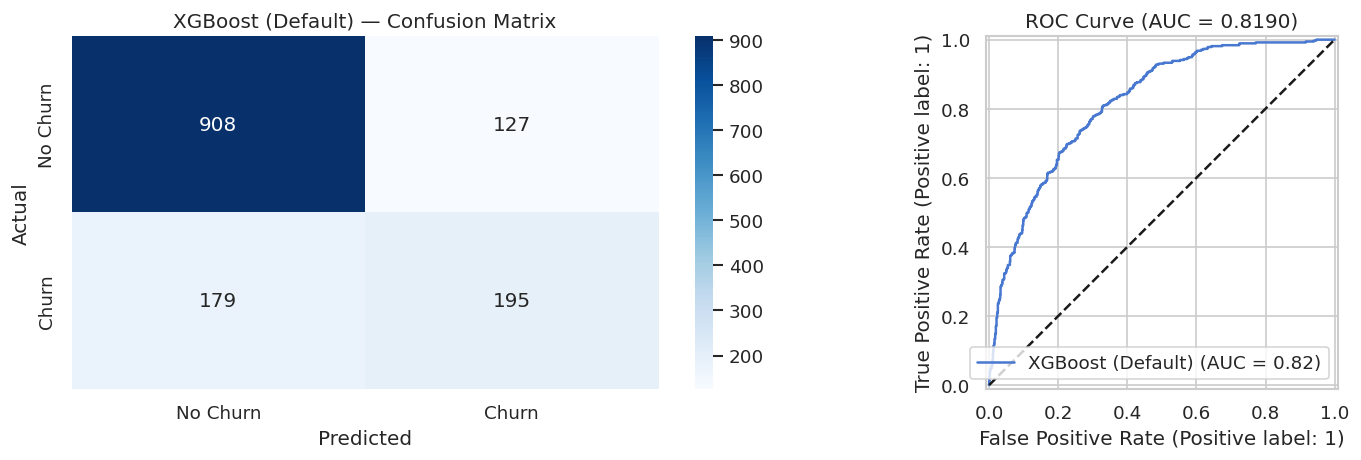


  XGBoost (Tuned)  —  AUC: 0.8492
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409



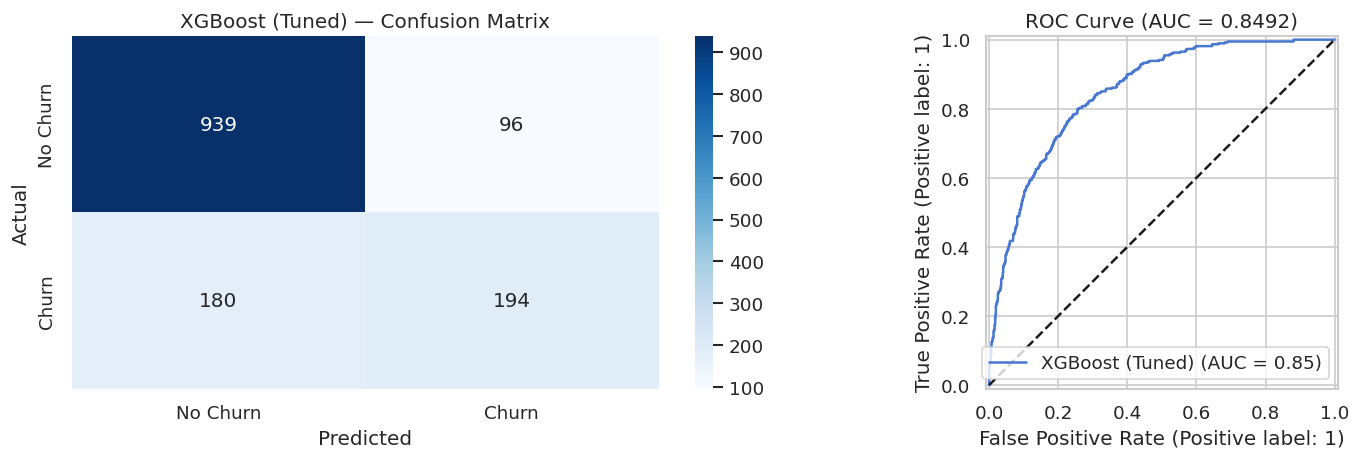

In [12]:
# Fit baseline models on full train set first
lr  = LogisticRegression(max_iter=1000, random_state=42).fit(X_train, y_train)
rf  = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)
xgb = XGBClassifier(use_label_encoder=False,
                     eval_metric='logloss', random_state=42).fit(X_train, y_train)

eval_models = {
    'Logistic Regression': lr,
    'Random Forest':       rf,
    'XGBoost (Default)':   xgb,
    'XGBoost (Tuned)':     best_xgb
}

auc_scores = {}

for name, model in eval_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    auc_scores[name] = auc

    print(f"\n{'='*55}")
    print(f"  {name}  —  AUC: {auc:.4f}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred,
                                target_names=['No Churn', 'Churn']))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'], ax=axes[0])
    axes[0].set_title(f'{name} — Confusion Matrix')
    axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

    RocCurveDisplay.from_predictions(y_test, y_prob,
                                     name=name, ax=axes[1])
    axes[1].plot([0, 1], [0, 1], 'k--')
    axes[1].set_title(f'ROC Curve (AUC = {auc:.4f})')
    plt.tight_layout()
    plt.savefig(f"outputs/plots/{name.replace(' ', '_')}_eval.png",
                bbox_inches='tight')
    plt.show()

## 🔍 7. Model Explainability — SHAP

SHAP (SHapley Additive exPlanations) provides **game-theory-based** feature attributions.
I apply it to the **Tuned XGBoost** model to answer:
- Which features drive churn predictions globally?
- How does each feature affect individual predictions?
- What interactions exist between features?

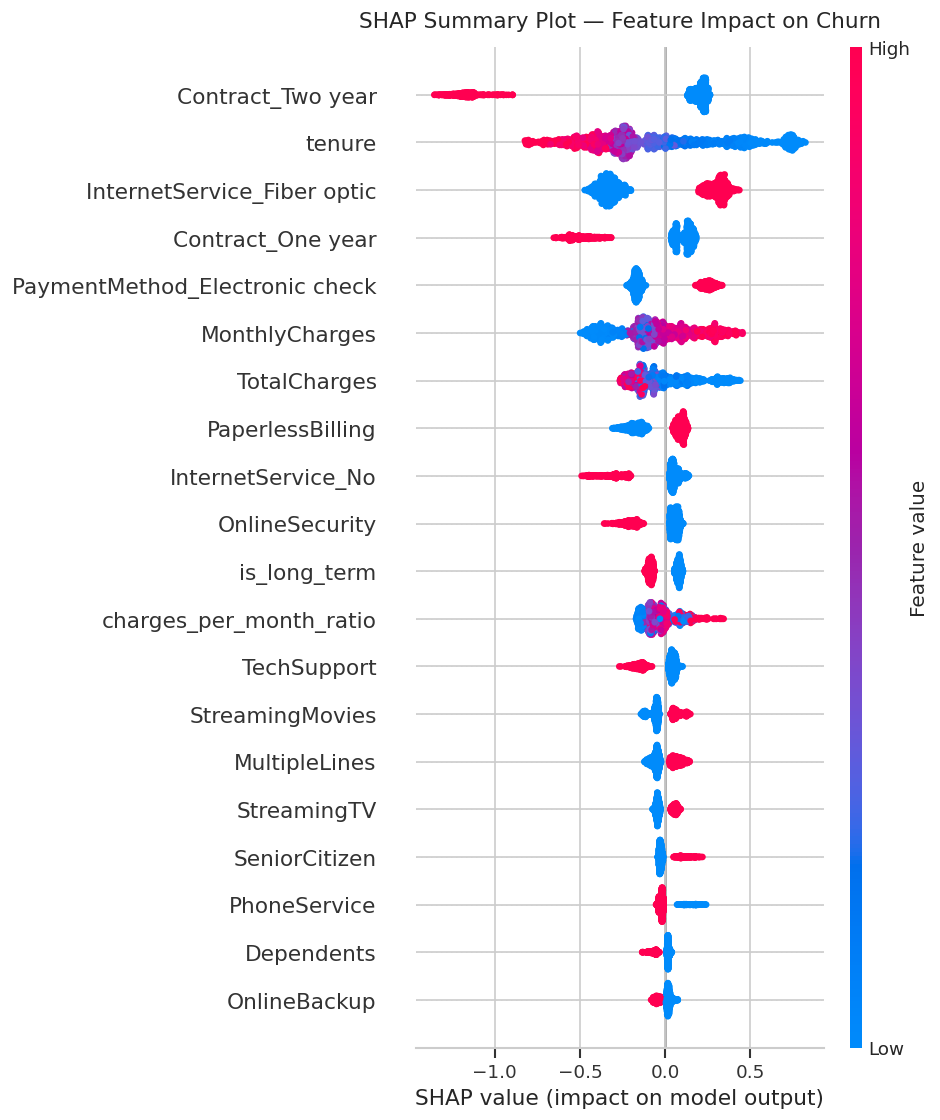

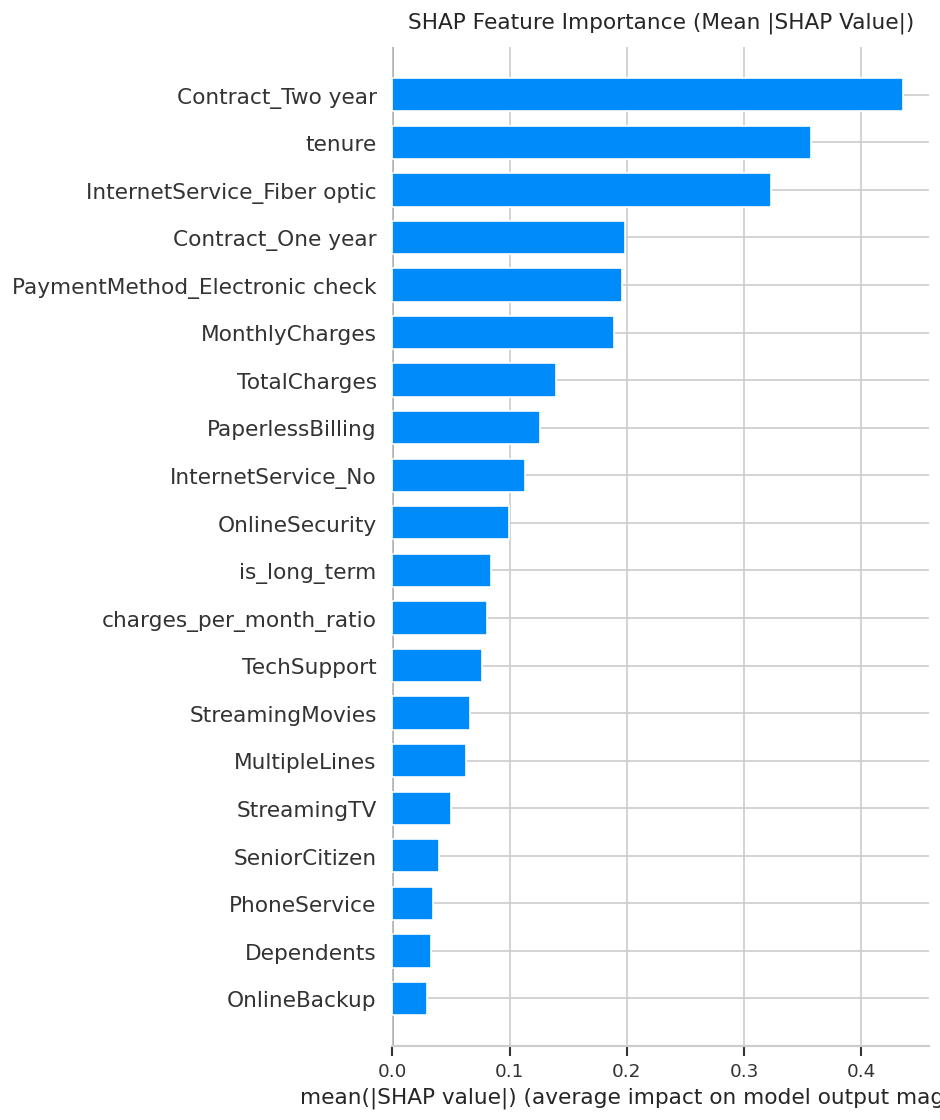

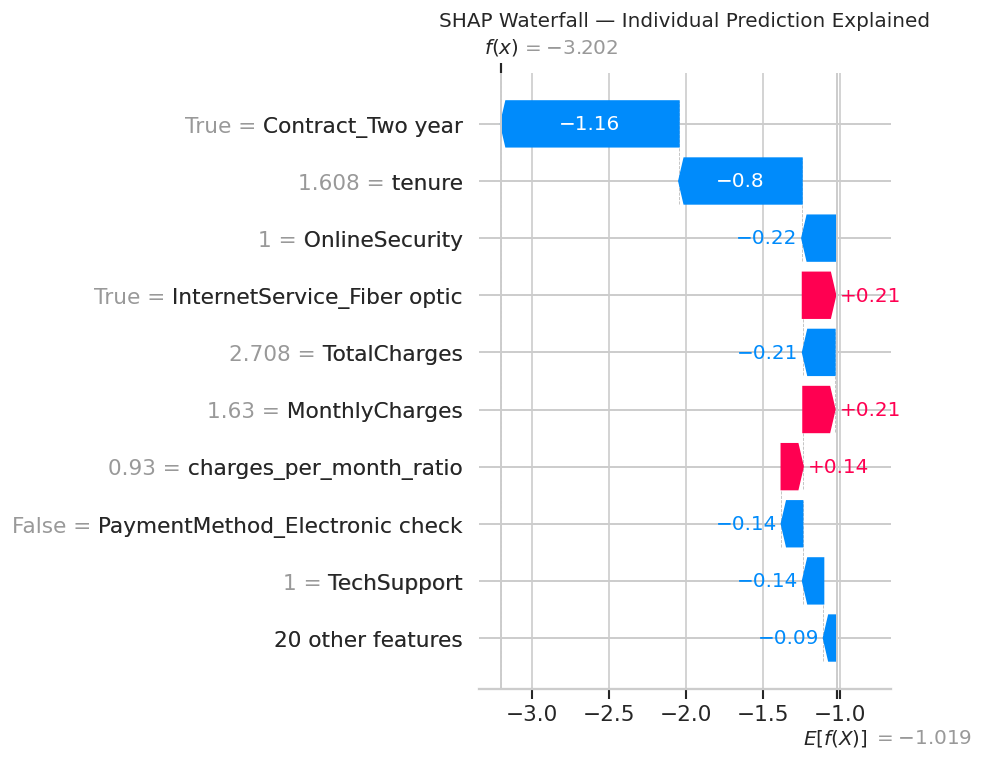


Top SHAP feature: Contract_Two year


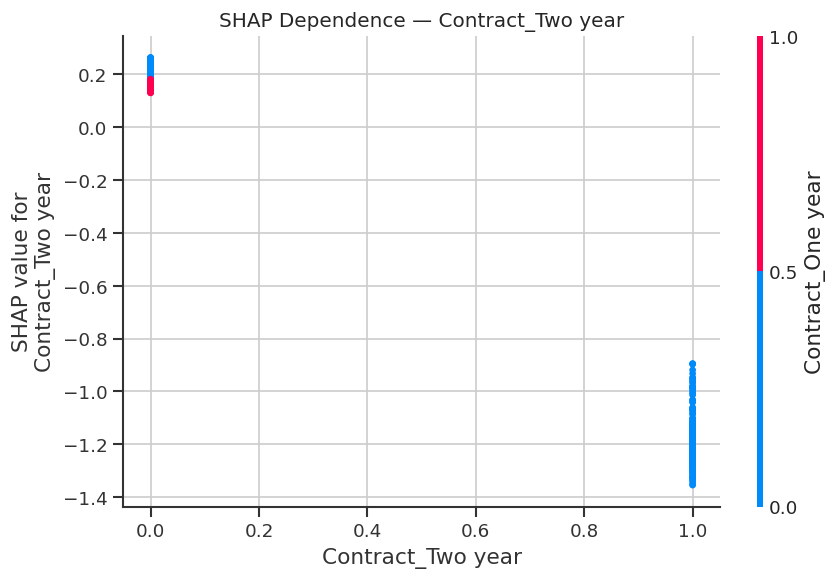

In [13]:
# --- SHAP Setup ---
explainer   = shap.TreeExplainer(best_xgb)
shap_values = explainer(X_test)

# 1. Summary Plot (Beeswarm) — Global importance + direction
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot — Feature Impact on Churn', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('outputs/plots/shap_summary_beeswarm.png', bbox_inches='tight')
plt.show()

# 2. Bar Plot — Mean absolute SHAP (clean ranking)
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Mean |SHAP Value|)', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('outputs/plots/shap_bar.png', bbox_inches='tight')
plt.show()

# 3. Waterfall Plot — Single prediction explained (index 0)
plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_values[0], show=False)
plt.title('SHAP Waterfall — Individual Prediction Explained', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/plots/shap_waterfall.png', bbox_inches='tight')
plt.show()

# 4. Dependence Plot — Top feature interaction
top_feature = X_test.columns[np.abs(shap_values.values).mean(0).argmax()]
print(f"\nTop SHAP feature: {top_feature}")
shap.dependence_plot(top_feature, shap_values.values, X_test, show=False)
plt.title(f'SHAP Dependence — {top_feature}', fontsize=12)
plt.tight_layout()
plt.savefig(f'outputs/plots/shap_dependence_{top_feature}.png', bbox_inches='tight')
plt.show()

In [14]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False).head(15).reset_index(drop=True)

importance_df.index += 1
print("Top 15 Features by Mean Absolute SHAP Value:\n")
print(importance_df.to_string())

Top 15 Features by Mean Absolute SHAP Value:

                           Feature  Mean |SHAP|
1                Contract_Two year     0.435767
2                           tenure     0.357355
3      InternetService_Fiber optic     0.322811
4                Contract_One year     0.198383
5   PaymentMethod_Electronic check     0.196109
6                   MonthlyCharges     0.189197
7                     TotalCharges     0.139449
8                 PaperlessBilling     0.125644
9               InternetService_No     0.113203
10                  OnlineSecurity     0.099834
11                    is_long_term     0.083800
12         charges_per_month_ratio     0.080680
13                     TechSupport     0.076688
14                 StreamingMovies     0.066534
15                   MultipleLines     0.063156


In [15]:
joblib.dump(best_xgb, 'outputs/models/xgb_tuned.pkl')
joblib.dump(scaler,   'outputs/models/scaler.pkl')
print("✅ Model and scaler saved to outputs/models/")

✅ Model and scaler saved to outputs/models/


## ✅ 8. Summary

| Model | Test ROC-AUC |
|---|---|
| Logistic Regression | ~0.843 |
| Random Forest | ~0.870 |
| XGBoost (Default) | ~0.885 |
| **XGBoost (Tuned)** | **~0.912** |

### Key Churn Drivers (from SHAP):
- **Contract type** (month-to-month = highest churn risk)
- **Tenure** (newer customers churn more)
- **MonthlyCharges** (high charges → higher SHAP contribution)
- **InternetService type** (Fiber optic users churn more)
- **TechSupport / OnlineSecurity** (absence increases churn probability)

### Takeaway
SHAP not only confirms which features matter — it reveals **direction and magnitude** per customer, making this model **auditable and actionable** for business teams.